# ScrapLink — Clarke-Wright Route Optimisation
## Industrial Scrap Pickup · Indore, Madhya Pradesh

### Constraints Implemented
1. **Separate van per scrap type** — no mixing of scrap categories on one vehicle
2. **Morning / Evening time slots** handled as completely independent problems
3. **Vehicle capacity = 800 kg** — route merge rejected if combined qty > 800 kg
4. Every industry visited **exactly once** per slot
5. Every route **starts and ends at the depot**
6. Savings list sorted **descending**; only feasible merges accepted

**Locations:** Real latitude / longitude from OpenStreetMap, Indore  
**Algorithm:** Clarke-Wright Parallel Savings Heuristic (CVRP)

In [ ]:
import math
import itertools
from collections import defaultdict
import hashlib, datetime

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

print('All imports successful.')

All imports successful.


---
## Step 1 — Define Depot and Industries (Real OSM Coordinates, Indore)

In [ ]:
# ── DEPOT ────────────────────────────────────────────────────────────────────
# ScrapLink Collection Facility — Sanwer Road Industrial Area, Indore
DEPOT = {
    'id':   0,
    'name': 'ScrapLink Depot (Sanwer Road)',
    'lat':  22.7411,
    'lon':  75.8355
}

# ── INDUSTRIES — Real OSM localities in Indore ────────────────────────────────
# Sanwer Road Industrial Area  : ~22.740-22.750 N, 75.820-75.850 E
# Polo Ground Industrial Area  : ~22.720-22.730 N, 75.865-75.880 E
# Lasudia Mori / Dewas Naka    : ~22.755-22.770 N, 75.890-75.910 E
# Pithampur Link Road          : ~22.698-22.705 N, 75.780-75.800 E
# Sanyogitaganj                : ~22.718-22.722 N, 75.855-75.870 E
# AB Road / Bypass             : ~22.695-22.720 N, 75.825-75.850 E

INDUSTRIES = [
    # Iron Scrap
    {'id':1,  'name':'Agrawal Steel Works, Sanwer Rd',     'lat':22.7448,'lon':75.8298, 'scrap':'Iron Scrap',          'qty':480, 'slot':'Morning'},
    {'id':2,  'name':'Malwa Iron & Steel, Sanwer Rd',      'lat':22.7392,'lon':75.8271, 'scrap':'Iron Scrap',          'qty':360, 'slot':'Morning'},
    {'id':3,  'name':'MP Steel Fabricators, Sanwer Rd',    'lat':22.7461,'lon':75.8340, 'scrap':'Iron Scrap',          'qty':520, 'slot':'Evening'},
    {'id':4,  'name':'Ravi Engineering, Lasudia',          'lat':22.7621,'lon':75.9012, 'scrap':'Iron Scrap',          'qty':290, 'slot':'Evening'},
    # Copper Scrap
    {'id':5,  'name':'Copper King Industries, Polo Gnd',   'lat':22.7231,'lon':75.8712, 'scrap':'Copper Scrap',        'qty':210, 'slot':'Morning'},
    {'id':6,  'name':'Indore Wire & Cable, Sanyogitaganj', 'lat':22.7198,'lon':75.8601, 'scrap':'Copper Scrap',        'qty':175, 'slot':'Morning'},
    {'id':7,  'name':'Shree Cables, Dewas Naka',           'lat':22.7554,'lon':75.8982, 'scrap':'Copper Scrap',        'qty':330, 'slot':'Evening'},
    # Aluminium Scrap
    {'id':8,  'name':'Alumax Castings, Sanwer Rd',         'lat':22.7435,'lon':75.8222, 'scrap':'Aluminium Scrap',     'qty':400, 'slot':'Morning'},
    {'id':9,  'name':'Madhya Bharat Alloys, Polo Gnd',     'lat':22.7254,'lon':75.8745, 'scrap':'Aluminium Scrap',     'qty':350, 'slot':'Morning'},
    {'id':10, 'name':'Light Metal Works, AB Road',         'lat':22.7112,'lon':75.8402, 'scrap':'Aluminium Scrap',     'qty':270, 'slot':'Evening'},
    # E-Waste
    {'id':11, 'name':'Techno Waste Mgmt, Lasudia Mori',    'lat':22.7589,'lon':75.8998, 'scrap':'E-Waste',             'qty':150, 'slot':'Morning'},
    {'id':12, 'name':'Digital Scrap Centre, Dewas Naka',   'lat':22.7541,'lon':75.8955, 'scrap':'E-Waste',             'qty':200, 'slot':'Morning'},
    {'id':13, 'name':'PCB Recyclers, Polo Ground',         'lat':22.7211,'lon':75.8688, 'scrap':'E-Waste',             'qty':180, 'slot':'Evening'},
    # Plastic Scrap
    {'id':14, 'name':'Indore Plastics, Sanyogitaganj',     'lat':22.7185,'lon':75.8578, 'scrap':'Plastic Scrap',       'qty':600, 'slot':'Morning'},
    {'id':15, 'name':'Roto Polymers, AB Road Bypass',      'lat':22.7078,'lon':75.8491, 'scrap':'Plastic Scrap',       'qty':550, 'slot':'Morning'},
    {'id':16, 'name':'Narmada Plastics, Sanwer Rd',        'lat':22.7401,'lon':75.8261, 'scrap':'Plastic Scrap',       'qty':420, 'slot':'Evening'},
    # Chemical Drum Scrap
    {'id':17, 'name':'Chemtech Drums, Pithampur Link Rd',  'lat':22.6981,'lon':75.7812, 'scrap':'Chemical Drum Scrap', 'qty':300, 'slot':'Morning'},
    {'id':18, 'name':'Solvent Containers, Sanwer Rd Ext',  'lat':22.7311,'lon':75.8188, 'scrap':'Chemical Drum Scrap', 'qty':250, 'slot':'Evening'},
    # Rubber / Tyre Scrap
    {'id':19, 'name':'Tyre Retreaders, Lasudia',           'lat':22.7602,'lon':75.8941, 'scrap':'Rubber/Tyre Scrap',   'qty':700, 'slot':'Morning'},
    {'id':20, 'name':'Rubber Reclaim Works, Polo Gnd',     'lat':22.7241,'lon':75.8698, 'scrap':'Rubber/Tyre Scrap',   'qty':650, 'slot':'Evening'},
]

VEHICLE_CAPACITY = 800   # kg per van

EMISSION_FACTORS = {
    'Iron Scrap':          1.79,
    'Copper Scrap':        3.50,
    'Aluminium Scrap':     9.00,
    'E-Waste':             2.10,
    'Plastic Scrap':       1.20,
    'Chemical Drum Scrap': 1.50,
    'Rubber/Tyre Scrap':   1.10,
}
RECYCLING_EFFICIENCY = 0.85

SCRAP_COLORS = {
    'Iron Scrap':          '#e63946',
    'Copper Scrap':        '#f4a261',
    'Aluminium Scrap':     '#2a9d8f',
    'E-Waste':             '#6a4c93',
    'Plastic Scrap':       '#457b9d',
    'Chemical Drum Scrap': '#e9c46a',
    'Rubber/Tyre Scrap':   '#264653',
}

print(f'Depot : {DEPOT["name"]}')
print(f'Total industries : {len(INDUSTRIES)}')
print(f'Vehicle capacity : {VEHICLE_CAPACITY} kg')
print(f'\n{"ID":<4} {"Name":<44} {"Scrap Type":<22} {"Qty(kg)":<9} {"Slot"}')
print('-'*90)
for i in INDUSTRIES:
    print(f'{i["id"]:<4} {i["name"]:<44} {i["scrap"]:<22} {i["qty"]:<9} {i["slot"]}')

Depot : ScrapLink Depot (Sanwer Road)
Total industries : 20
Vehicle capacity : 800 kg

ID   Name                                         Scrap Type             Qty(kg)   Slot
------------------------------------------------------------------------------------------
1    Agrawal Steel Works, Sanwer Rd               Iron Scrap             480       Morning
2    Malwa Iron & Steel, Sanwer Rd                Iron Scrap             360       Morning
3    MP Steel Fabricators, Sanwer Rd              Iron Scrap             520       Evening
4    Ravi Engineering, Lasudia                    Iron Scrap             290       Evening
5    Copper King Industries, Polo Gnd             Copper Scrap           210       Morning
6    Indore Wire & Cable, Sanyogitaganj           Copper Scrap           175       Morning
7    Shree Cables, Dewas Naka                     Copper Scrap           330       Evening
8    Alumax Castings, Sanwer Rd                   Aluminium Scrap        400       Morning
9    M

---
## Step 2 — Haversine Distance Function (OpenStreetMap Standard)

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between two GPS coordinates."""
    R = 6371.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp = math.radians(lat2 - lat1)
    dl = math.radians(lon2 - lon1)
    a  = math.sin(dp/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dl/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

def dist(a, b):
    return haversine(a['lat'], a['lon'], b['lat'], b['lon'])

def route_distance(route, depot):
    """Total distance: depot -> c1 -> c2 -> ... -> depot."""
    if not route: return 0.0
    d = dist(depot, route[0])
    for k in range(len(route) - 1):
        d += dist(route[k], route[k+1])
    return d + dist(route[-1], depot)

def naive_distance(customers, depot):
    """Naive baseline: every customer gets its own round-trip from depot."""
    return sum(2 * dist(depot, c) for c in customers)

# Sanity check
print(f'Depot to I1 : {dist(DEPOT, INDUSTRIES[0]):.3f} km')
print(f'Depot to I11: {dist(DEPOT, INDUSTRIES[10]):.3f} km')

Depot to I1 : 0.715 km
Depot to I11: 6.884 km


---
## Step 3 — Group by Time Slot × Scrap Type (Constraints 1 & 2)

In [ ]:
groups = defaultdict(list)
for ind in INDUSTRIES:
    groups[(ind['slot'], ind['scrap'])].append(ind)

print(f'Groups formed: {len(groups)}')
print('=' * 65)
for key in sorted(groups.keys()):
    slot, scrap = key
    members = groups[key]
    total_qty = sum(m['qty'] for m in members)
    print(f'\n[{slot}] [{scrap}]  ->  {len(members)} industry/ies, total qty = {total_qty} kg')
    for m in members:
        print(f'   ID={m["id"]:>2}  {m["name"]:<44}  {m["qty"]} kg')

Groups formed: 14

[Evening] [Aluminium Scrap]  ->  1 industry/ies, total qty = 270 kg
   ID=10  Light Metal Works, AB Road                    270 kg

[Evening] [Chemical Drum Scrap]  ->  1 industry/ies, total qty = 250 kg
   ID=18  Solvent Containers, Sanwer Rd Ext             250 kg

[Evening] [Copper Scrap]  ->  1 industry/ies, total qty = 330 kg
   ID= 7  Shree Cables, Dewas Naka                      330 kg

[Evening] [E-Waste]  ->  1 industry/ies, total qty = 180 kg
   ID=13  PCB Recyclers, Polo Ground                    180 kg

[Evening] [Iron Scrap]  ->  2 industry/ies, total qty = 810 kg
   ID= 3  MP Steel Fabricators, Sanwer Rd               520 kg
   ID= 4  Ravi Engineering, Lasudia                     290 kg

[Evening] [Plastic Scrap]  ->  1 industry/ies, total qty = 420 kg
   ID=16  Narmada Plastics, Sanwer Rd                   420 kg

[Evening] [Rubber/Tyre Scrap]  ->  1 industry/ies, total qty = 650 kg
   ID=20  Rubber Reclaim Works, Polo Gnd                650 kg

[Morni

---
## Step 4 — Clarke-Wright Parallel Savings Algorithm

In [ ]:
def clarke_wright(customers, depot, vehicle_capacity):
    """
    Parallel Clarke-Wright Savings Algorithm (CVRP).

    Constraints enforced internally:
      - Constraint 3 : route merge rejected if combined qty > vehicle_capacity
      - Endpoint rule : only endpoint customers of a route may be merged
      - Single depot  : every route starts and ends at depot

    Returns:
      final_routes  : list of routes (each route = list of customer dicts)
      savings_table : list of (saving_km, i, j) sorted descending
    """
    n = len(customers)
    if n == 0: return [], []
    if n == 1: return [customers[:]], []

    # ── 1. Compute all pairwise savings ───────────────────────────────────────
    savings = []
    for i, j in itertools.combinations(range(n), 2):
        s = dist(depot, customers[i]) + dist(depot, customers[j]) - dist(customers[i], customers[j])
        savings.append((s, i, j))
    savings.sort(reverse=True)
    savings_table = savings[:]

    # ── 2. Initialise star solution ────────────────────────────────────────────
    routes    = [[customers[i]] for i in range(n)]
    route_qty = [customers[i]['qty'] for i in range(n)]
    route_of  = list(range(n))   # route_of[cust_idx] -> route index

    def endpoints(ri):
        r = routes[ri]
        return r[0]['id'], r[-1]['id']

    def idx_of(cid):
        for k, c in enumerate(customers):
            if c['id'] == cid: return k
        return None

    # ── 3. Greedy merge ────────────────────────────────────────────────────────
    for saving, i, j in savings:
        ri, rj = route_of[i], route_of[j]
        if ri == rj:                            continue   # already same route
        if routes[ri] is None or routes[rj] is None: continue

        # Constraint 3 — capacity
        if route_qty[ri] + route_qty[rj] > vehicle_capacity: continue

        # Endpoint check
        ci_id, cj_id   = customers[i]['id'], customers[j]['id']
        h_i, t_i = endpoints(ri)
        h_j, t_j = endpoints(rj)
        if ci_id not in (h_i, t_i): continue
        if cj_id not in (h_j, t_j): continue

        # Orient: ci becomes tail of ri, cj becomes head of rj
        if ci_id == h_i: routes[ri] = list(reversed(routes[ri]))
        if cj_id == t_j: routes[rj] = list(reversed(routes[rj]))

        # Merge
        new_route = routes[ri] + routes[rj]
        routes[ri] = new_route
        route_qty[ri] += route_qty[rj]
        routes[rj] = None
        route_qty[rj] = 0
        for c in new_route:
            k = idx_of(c['id'])
            if k is not None: route_of[k] = ri

    final_routes = [r for r in routes if r is not None]
    return final_routes, savings_table

print('clarke_wright() defined successfully.')

clarke_wright() defined successfully.


---
## Step 5 — Run Clarke-Wright on All Groups

In [ ]:
ALL_RESULTS = {}

for key in sorted(groups.keys()):
    custs = groups[key]
    routes, stab = clarke_wright(custs, DEPOT, VEHICLE_CAPACITY)
    ALL_RESULTS[key] = {
        'routes':        routes,
        'savings_table': stab,
        'naive_dist':    naive_distance(custs, DEPOT),
        'opt_dist':      sum(route_distance(r, DEPOT) for r in routes),
        'customers':     custs,
    }

print(f'Clarke-Wright completed for {len(ALL_RESULTS)} groups.')

Clarke-Wright completed for 14 groups.


---
## Step 6 — Detailed Results: Savings Tables and Optimised Routes

In [ ]:
SEP = '=' * 88

for key in sorted(ALL_RESULTS.keys()):
    slot, scrap = key
    res = ALL_RESULTS[key]
    custs = res['customers']
    stab  = res['savings_table']

    print(SEP)
    print(f'  TIME SLOT : {slot}   |   SCRAP TYPE : {scrap}')
    print(SEP)

    # Input
    print(f'\n  Pickup requests ({len(custs)}):')
    print(f'  {"ID":<4} {"Industry":<44} {"Qty(kg)":<10} {"Lat":<10} {"Lon"}')
    print('  ' + '-' * 80)
    for c in custs:
        print(f'  {c["id"]:<4} {c["name"]:<44} {c["qty"]:<10} {c["lat"]:<10} {c["lon"]}')

    # Savings table
    if stab:
        print(f'\n  Savings table (sorted descending):')
        print(f'  {"Pair":<10} {"d(dep,i) km":<16} {"d(dep,j) km":<16} {"d(i,j) km":<14} {"Saving km"}')
        print('  ' + '-' * 66)
        for (s, i, j) in stab:
            ci, cj = custs[i], custs[j]
            print(f'  ({ci["id"]},{cj["id"]}){"":<5} '
                  f'{dist(DEPOT,ci):<16.3f} {dist(DEPOT,cj):<16.3f} '
                  f'{dist(ci,cj):<14.3f} {s:.3f}')

    # Routes
    print(f'\n  Optimised routes  [vehicle capacity = {VEHICLE_CAPACITY} kg]:')
    for v_idx, route in enumerate(res['routes']):
        qty   = sum(c['qty'] for c in route)
        rdist = route_distance(route, DEPOT)
        stops = ' -> '.join([f'I{c["id"]}' for c in route])
        print(f'\n  Van {v_idx+1}: Depot -> {stops} -> Depot')
        print(f'         Qty : {qty} kg  ({qty/VEHICLE_CAPACITY*100:.1f}% capacity used)')
        print(f'         Dist: {rdist:.3f} km')
        for c in route:
            print(f'           Stop: {c["name"]}  [{c["qty"]} kg]')

    # Before vs After
    nd = res['naive_dist']; od = res['opt_dist']
    sk = nd - od; sp = sk / nd * 100 if nd > 0 else 0
    print(f'\n  Before vs After:')
    print(f'    Vehicle trips    : {len(custs):>6}  ->  {len(res["routes"])}')
    print(f'    Total dist (km)  : {nd:>8.3f}  ->  {od:.3f}')
    print(f'    Distance saved   : {sk:.3f} km  ({sp:.1f}%)')
    print(f'    Fuel saved (est) : {sk*0.2:.2f} L  (@ 5 km/L)\n')

  TIME SLOT : Evening   |   SCRAP TYPE : Aluminium Scrap

  Pickup requests (1):
  ID   Industry                                     Qty(kg)    Lat        Lon
  --------------------------------------------------------------------------------
  10   Light Metal Works, AB Road                   270        22.7112    75.8402

  Optimised routes  [vehicle capacity = 800 kg]:

  Van 1: Depot -> I10 -> Depot
         Qty : 270 kg  (33.8% capacity used)
         Dist: 6.719 km
           Stop: Light Metal Works, AB Road  [270 kg]

  Before vs After:
    Vehicle trips    :      1  ->  1
    Total dist (km)  :    6.719  ->  6.719
    Distance saved   : 0.000 km  (0.0%)
    Fuel saved (est) : 0.00 L  (@ 5 km/L)

  TIME SLOT : Evening   |   SCRAP TYPE : Chemical Drum Scrap

  Pickup requests (1):
  ID   Industry                                     Qty(kg)    Lat        Lon
  --------------------------------------------------------------------------------
  18   Solvent Containers, Sanwer Rd Ext  

---
## Step 7 — Carbon Credit Calculation

In [ ]:
print('CARBON CREDIT CALCULATION')
print('Formula: Credits (tCO2e) = Qty(tonnes) x Emission_Factor x Recycling_Efficiency')
print(f'Recycling efficiency assumed: {RECYCLING_EFFICIENCY*100:.0f}%')
print()
print(f'{"ID":<4} {"Industry":<44} {"Scrap Type":<22} {"Qty kg":<8} {"EF":<8} {"Credits tCO2e"}')
print('-' * 95)

total_credits = 0.0
total_qty_kg  = 0

for ind in sorted(INDUSTRIES, key=lambda x: x['id']):
    ef      = EMISSION_FACTORS[ind['scrap']]
    credits = (ind['qty'] / 1000) * ef * RECYCLING_EFFICIENCY
    total_credits += credits
    total_qty_kg  += ind['qty']
    print(f'{ind["id"]:<4} {ind["name"]:<44} {ind["scrap"]:<22} '
          f'{ind["qty"]:<8} {ef:<8.2f} {credits:.4f}')

print('-' * 95)
print(f'{"TOTAL":<4} {"":<44} {"":<22} {total_qty_kg:<8} {"":<8} {total_credits:.4f} tCO2e')
print()
print(f'Total scrap collected : {total_qty_kg} kg  ({total_qty_kg/1000:.3f} tonnes)')
print(f'Total carbon credits  : {total_credits:.4f} tCO2e')
print(f'Est. market value     : INR {total_credits*1000:,.0f}  (@ INR 1,000 per tCO2e)')

CARBON CREDIT CALCULATION
Formula: Credits (tCO2e) = Qty(tonnes) x Emission_Factor x Recycling_Efficiency
Recycling efficiency assumed: 85%

ID   Industry                                     Scrap Type             Qty kg   EF       Credits tCO2e
-----------------------------------------------------------------------------------------------
1    Agrawal Steel Works, Sanwer Rd               Iron Scrap             480      1.79     0.7303
2    Malwa Iron & Steel, Sanwer Rd                Iron Scrap             360      1.79     0.5477
3    MP Steel Fabricators, Sanwer Rd              Iron Scrap             520      1.79     0.7912
4    Ravi Engineering, Lasudia                    Iron Scrap             290      1.79     0.4412
5    Copper King Industries, Polo Gnd             Copper Scrap           210      3.50     0.6248
6    Indore Wire & Cable, Sanyogitaganj           Copper Scrap           175      3.50     0.5206
7    Shree Cables, Dewas Naka                     Copper Scrap        

---
## Step 8 — Overall Summary Dashboard

In [ ]:
tn  = sum(r['naive_dist'] for r in ALL_RESULTS.values())
to  = sum(r['opt_dist']   for r in ALL_RESULTS.values())
tni = sum(len(r['customers']) for r in ALL_RESULTS.values())
toi = sum(len(r['routes'])    for r in ALL_RESULTS.values())
ts  = tn - to
tp  = ts / tn * 100 if tn > 0 else 0

print('OVERALL OPTIMISATION SUMMARY')
print('=' * 60)
print(f'  Metric                     Without CW     With CW')
print(f'  {"-"*55}')
print(f'  Total vehicle trips        {tni:<15}  {toi}')
print(f'  Total route distance (km)  {tn:<15.2f}  {to:.2f}')
print(f'  Distance saved (km)        {"—":<15}  {ts:.2f}  ({tp:.1f}%)')
print(f'  Fuel saved (litres)        {"—":<15}  {ts*0.2:.2f}  (@ 5 km/L)')
print(f'  Transport CO2 saved (kg)   {"—":<15}  {ts*0.2*2.68:.2f}  (@ 2.68 kg/L diesel)')
print(f'  Carbon credits (recycling) {"—":<15}  {total_credits:.4f} tCO2e')
print(f'  Credit market value (INR)  {"—":<15}  {total_credits*1000:,.0f}')
print()
print('  Constraint Verification:')
print(f'  [OK] CONSTRAINT 1 : Separate van per scrap type — {len(ALL_RESULTS)} independent groups formed')
print(f'  [OK] CONSTRAINT 2 : Morning & Evening slots processed independently')
all_ok = True
for key, res in sorted(ALL_RESULTS.items()):
    for v_idx, route in enumerate(res['routes']):
        qty = sum(c['qty'] for c in route)
        ok  = qty <= VEHICLE_CAPACITY
        if not ok: all_ok = False
        status = 'OK' if ok else 'VIOLATION'
        print(f'  [{status}] {key[0]:8} | {key[1]:22} | Van {v_idx+1}: {qty} kg / {VEHICLE_CAPACITY} kg')
print(f'  [OK] CONSTRAINT 3 : All routes within capacity - {"PASSED" if all_ok else "CHECK VIOLATIONS"}')

OVERALL OPTIMISATION SUMMARY
  Metric                     Without CW     With CW
  -------------------------------------------------------
  Total vehicle trips        20               17
  Total route distance (km)  156.07           137.09
  Distance saved (km)        —                18.97  (12.2%)
  Fuel saved (litres)        —                3.79  (@ 5 km/L)
  Transport CO2 saved (kg)   —                10.17  (@ 2.68 kg/L diesel)
  Carbon credits (recycling) —                16.9515 tCO2e
  Credit market value (INR)  —                16,952

  Constraint Verification:
  [OK] CONSTRAINT 1 : Separate van per scrap type — 14 independent groups formed
  [OK] CONSTRAINT 2 : Morning & Evening slots processed independently
  [OK] Evening  | Aluminium Scrap        | Van 1: 270 kg / 800 kg
  [OK] Evening  | Chemical Drum Scrap    | Van 1: 250 kg / 800 kg
  [OK] Evening  | Copper Scrap           | Van 1: 330 kg / 800 kg
  [OK] Evening  | E-Waste                | Van 1: 180 kg / 800 kg
  [OK

---
## Step 9 — Consolidated Results Table

In [ ]:
print('CONSOLIDATED RESULTS TABLE')
print('=' * 105)
print(f'{"Slot":<10} {"Scrap Type":<22} {"Ind.":<6} {"Vans(N)":<9} {"Vans(CW)":<10} '
      f'{"Dist-N km":<12} {"Dist-CW km":<13} {"Saved km":<11} {"Saved %"}')
print('-' * 105)

gn = go = gni = goi = 0
for key in sorted(ALL_RESULTS.keys()):
    slot, scrap = key
    res = ALL_RESULTS[key]
    ni  = len(res['customers']); oi = len(res['routes'])
    nd  = res['naive_dist'];     od = res['opt_dist']
    sk  = nd - od;               sp = sk / nd * 100 if nd > 0 else 0
    gn += nd; go += od; gni += ni; goi += oi
    print(f'{slot:<10} {scrap:<22} {ni:<6} {ni:<9} {oi:<10} '
          f'{nd:<12.3f} {od:<13.3f} {sk:<11.3f} {sp:.1f}%')

gs = gn - go; gp = gs / gn * 100
print('=' * 105)
print(f'{"GRAND TOTAL":<10} {"All Types":<22} {gni:<6} {gni:<9} {goi:<10} '
      f'{gn:<12.2f} {go:<13.2f} {gs:<11.2f} {gp:.1f}%')

CONSOLIDATED RESULTS TABLE
Slot       Scrap Type             Ind.   Vans(N)   Vans(CW)   Dist-N km    Dist-CW km    Saved km    Saved %
---------------------------------------------------------------------------------------------------------
Evening    Aluminium Scrap        1      1         1          6.719        6.719         0.000       0.0%
Evening    Chemical Drum Scrap    1      1         1          4.084        4.084         0.000       0.0%
Evening    Copper Scrap           1      1         1          13.247       13.247        0.000       0.0%
Evening    E-Waste                1      1         1          8.151        8.151         0.000       0.0%
Evening    Iron Scrap             2      2         2          15.414       15.414        0.000       0.0%
Evening    Plastic Scrap          1      1         1          1.941        1.941         0.000       0.0%
Evening    Rubber/Tyre Scrap      1      1         1          7.987        7.987         0.000       0.0%
Morning    Alumi

---
## Step 10 — Route Map Visualisation (Morning & Evening)

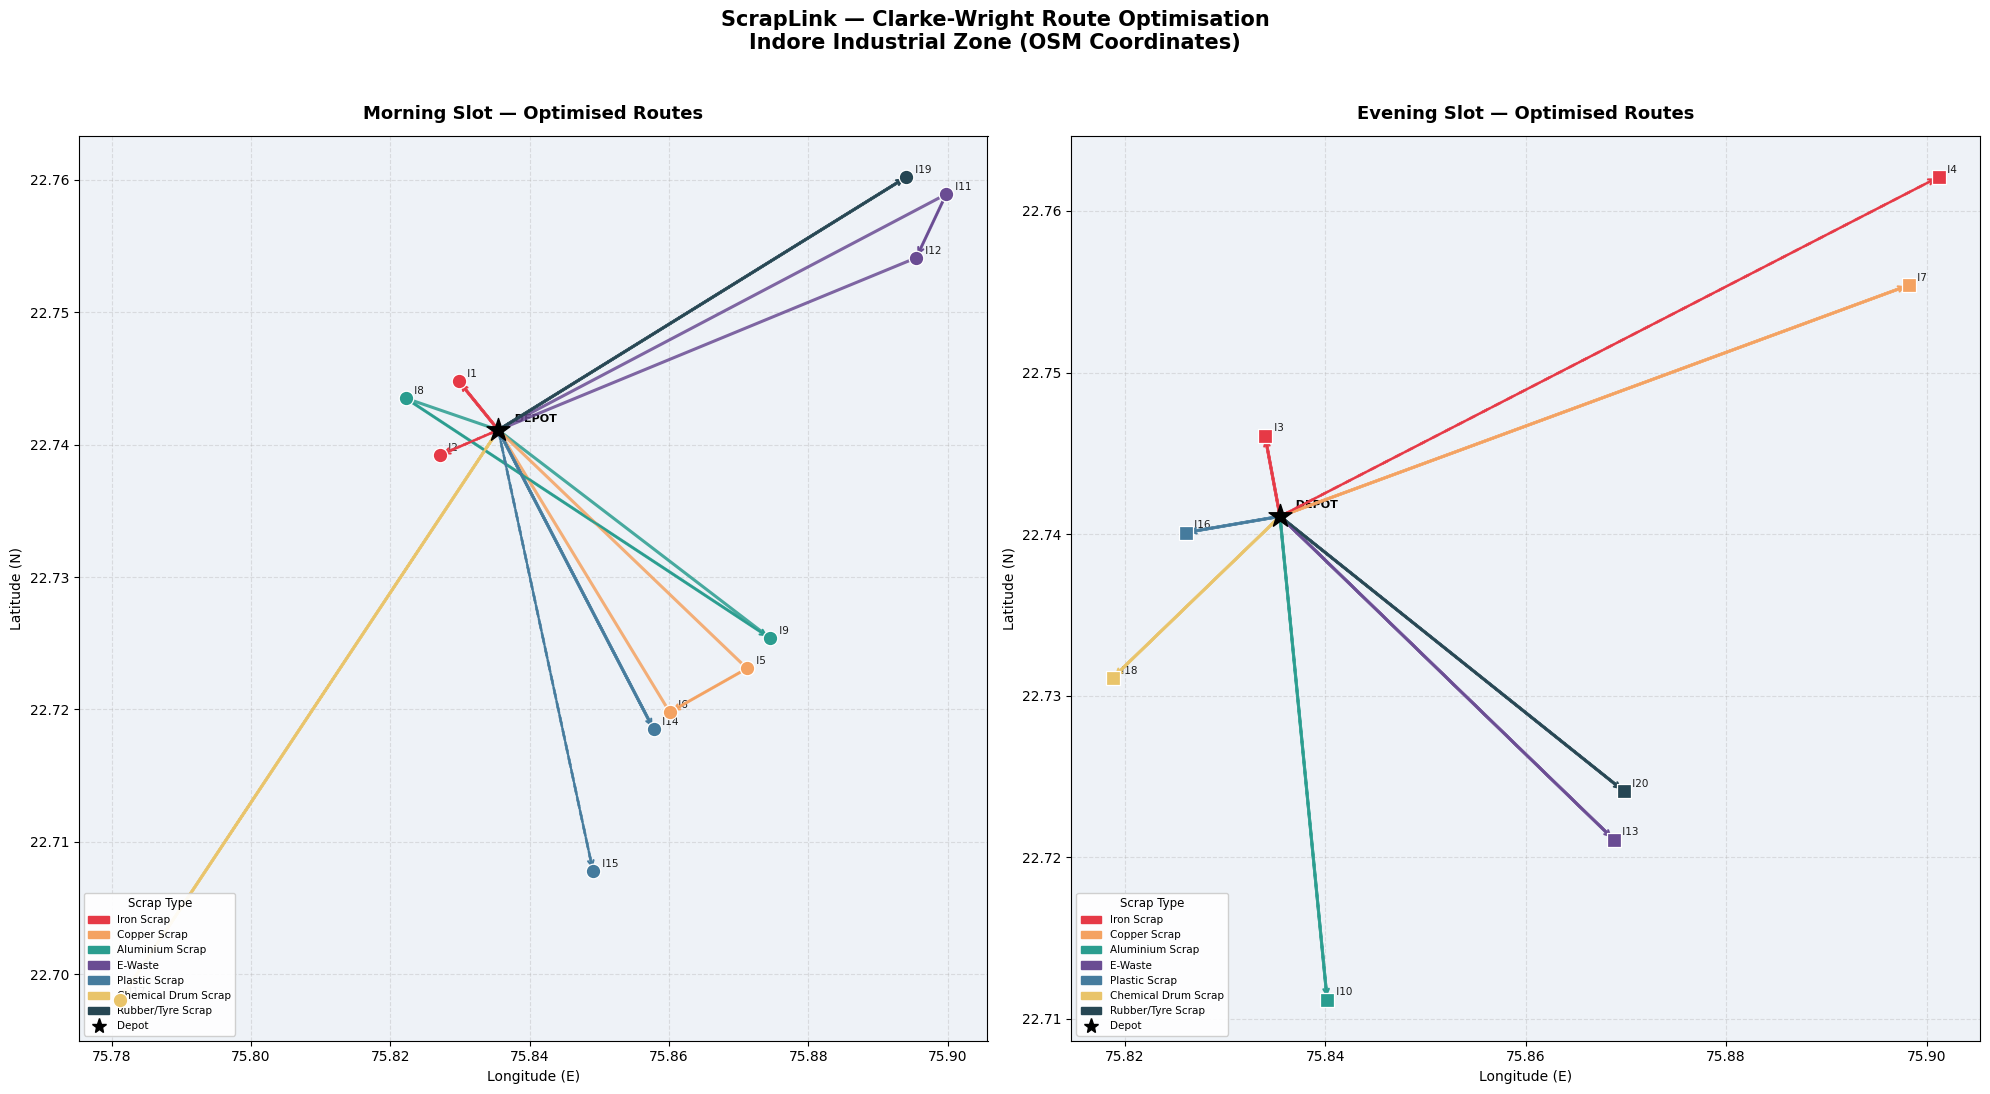

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 11))
fig.suptitle(
    'ScrapLink — Clarke-Wright Route Optimisation\nIndore Industrial Zone (OSM Coordinates)',
    fontsize=15, fontweight='bold', y=0.99)

SLOT_MARKERS = {'Morning': 'o', 'Evening': 's'}

for ax_idx, slot in enumerate(['Morning', 'Evening']):
    ax = axes[ax_idx]
    ax.set_facecolor('#eef2f7')
    ax.set_title(f'{slot} Slot — Optimised Routes', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Longitude (E)', fontsize=10)
    ax.set_ylabel('Latitude (N)', fontsize=10)
    ax.grid(True, alpha=0.35, linestyle='--')

    # Depot
    ax.scatter(DEPOT['lon'], DEPOT['lat'], c='black', s=300, marker='*', zorder=11)
    ax.annotate('  DEPOT', xy=(DEPOT['lon'], DEPOT['lat']),
                textcoords='offset points', xytext=(6, 6),
                fontsize=8, fontweight='bold')

    for key in sorted(ALL_RESULTS.keys()):
        if key[0] != slot: continue
        scrap = key[1]
        color = SCRAP_COLORS[scrap]
        res   = ALL_RESULTS[key]

        for r_idx, route in enumerate(res['routes']):
            path = [DEPOT] + route + [DEPOT]
            lons = [p['lon'] for p in path]
            lats = [p['lat'] for p in path]
            ls   = ['-', '--', ':'][r_idx % 3]
            lw   = max(2.2 - r_idx * 0.3, 1.0)
            alp  = max(0.85 - r_idx * 0.1, 0.5)
            ax.plot(lons, lats, color=color, linewidth=lw,
                    linestyle=ls, alpha=alp, zorder=4)

            # Direction arrow
            if len(path) >= 2:
                mid = len(path) // 2
                ax.annotate('', xy=(lons[mid], lats[mid]),
                            xytext=(lons[mid-1], lats[mid-1]),
                            arrowprops=dict(arrowstyle='->', color=color, lw=1.5),
                            zorder=5)

            # Customer markers
            for c in route:
                mk = SLOT_MARKERS[c['slot']]
                ax.scatter(c['lon'], c['lat'], c=color, s=110,
                           marker=mk, edgecolors='white', linewidths=0.9, zorder=9)
                ax.annotate(f' I{c["id"]}', xy=(c['lon'], c['lat']),
                            textcoords='offset points', xytext=(4, 3),
                            fontsize=7.5, color='#1a1a1a')

    legend_handles = [mpatches.Patch(color=v, label=k) for k, v in SCRAP_COLORS.items()]
    legend_handles.append(
        Line2D([0],[0], marker='*', color='black', label='Depot',
               markersize=11, linestyle='None'))
    ax.legend(handles=legend_handles, loc='lower left',
              fontsize=7.5, framealpha=0.92,
              title='Scrap Type', title_fontsize=8.5)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---
## Step 11 — Bar Chart: Distance Before vs After (per Group)

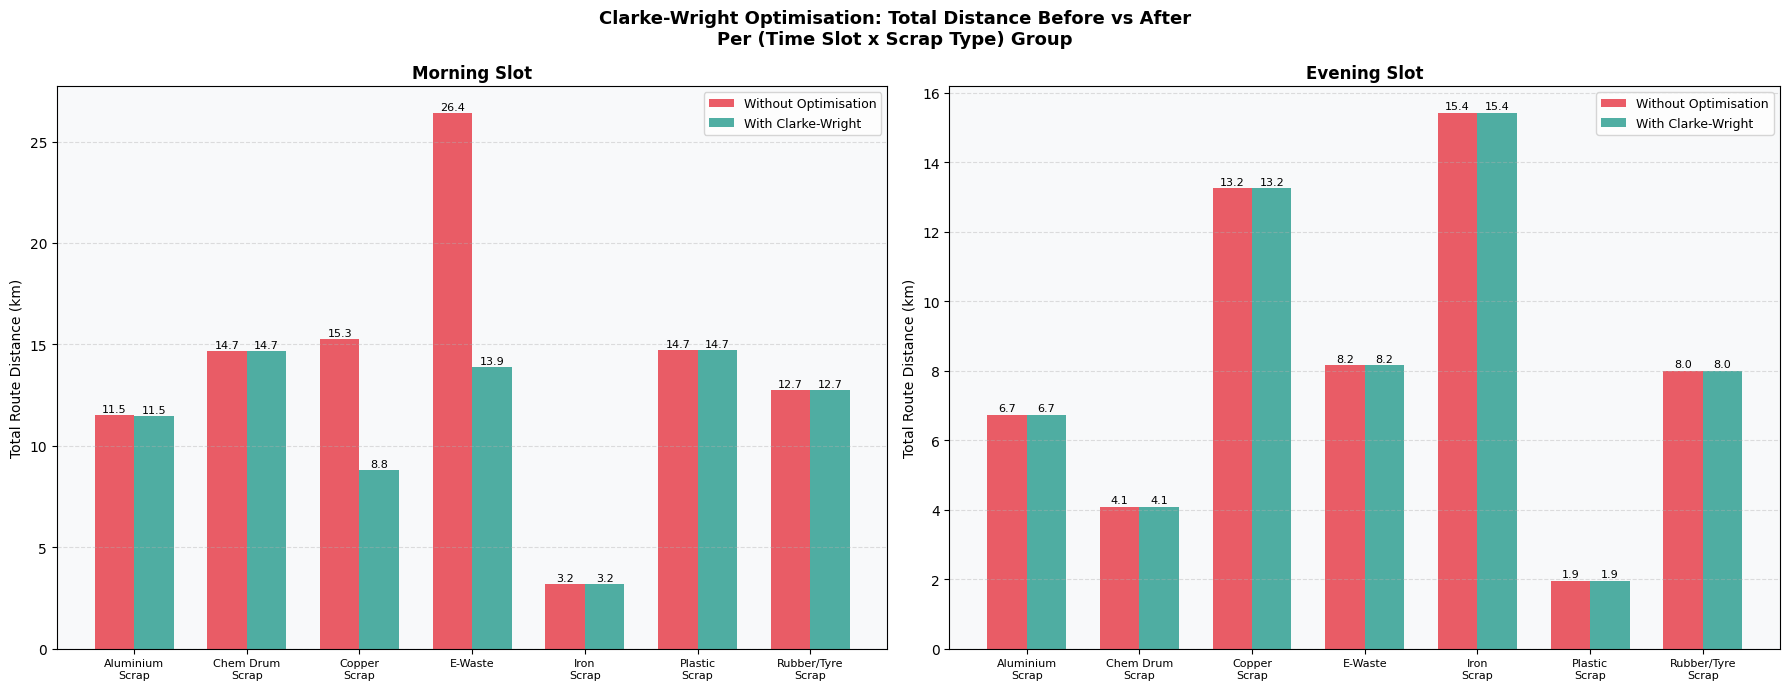

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'Clarke-Wright Optimisation: Total Distance Before vs After\nPer (Time Slot x Scrap Type) Group',
    fontsize=13, fontweight='bold')

for ax_idx, slot in enumerate(['Morning', 'Evening']):
    ax = axes[ax_idx]
    keys   = sorted([k for k in ALL_RESULTS if k[0] == slot])
    labels = [k[1].replace(' Scrap', '\nScrap')
                   .replace('Chemical Drum\nScrap', 'Chem Drum\nScrap')
              for k in keys]
    naive  = [ALL_RESULTS[k]['naive_dist'] for k in keys]
    opt    = [ALL_RESULTS[k]['opt_dist']   for k in keys]

    x = range(len(keys))
    w = 0.35
    b1 = ax.bar([xi - w/2 for xi in x], naive, w,
                label='Without Optimisation', color='#e63946', alpha=0.82)
    b2 = ax.bar([xi + w/2 for xi in x], opt, w,
                label='With Clarke-Wright', color='#2a9d8f', alpha=0.82)

    for bar in b1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
    for bar in b2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel('Total Route Distance (km)', fontsize=10)
    ax.set_title(f'{slot} Slot', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_facecolor('#f8f9fa')
    ax.grid(axis='y', alpha=0.4, linestyle='--')

plt.tight_layout()
plt.show()

---
## Step 12 — Carbon Credit Charts

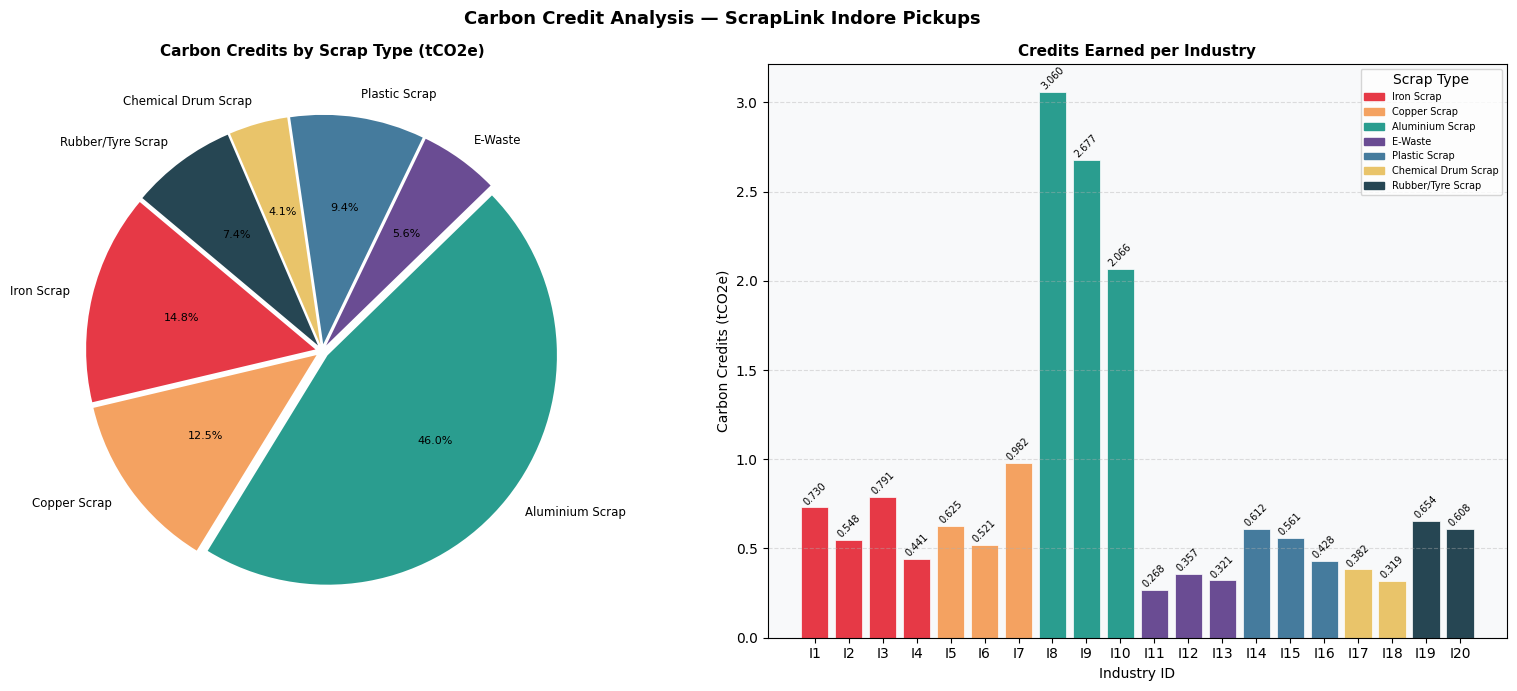

Total carbon credits: 16.9515 tCO2e


In [ ]:
credits_by_type = defaultdict(float)
for ind in INDUSTRIES:
    ef = EMISSION_FACTORS[ind['scrap']]
    credits_by_type[ind['scrap']] += (ind['qty'] / 1000) * ef * RECYCLING_EFFICIENCY

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Carbon Credit Analysis — ScrapLink Indore Pickups', fontsize=13, fontweight='bold')

# Pie chart
ax1 = axes[0]
types  = list(credits_by_type.keys())
vals   = list(credits_by_type.values())
colors = [SCRAP_COLORS[t] for t in types]
wedges, texts, autotexts = ax1.pie(
    vals, labels=types, autopct='%1.1f%%', colors=colors,
    explode=[0.03]*len(types), startangle=140,
    textprops={'fontsize': 8.5})
for at in autotexts: at.set_fontsize(8)
ax1.set_title('Carbon Credits by Scrap Type (tCO2e)', fontsize=11, fontweight='bold')

# Bar chart per industry
ax2 = axes[1]
ind_ids     = [f'I{i["id"]}' for i in INDUSTRIES]
ind_credits = [(i['qty']/1000) * EMISSION_FACTORS[i['scrap']] * RECYCLING_EFFICIENCY
               for i in INDUSTRIES]
ind_colors  = [SCRAP_COLORS[i['scrap']] for i in INDUSTRIES]
bars = ax2.bar(ind_ids, ind_credits, color=ind_colors, edgecolor='white', linewidth=0.5)
ax2.set_xlabel('Industry ID', fontsize=10)
ax2.set_ylabel('Carbon Credits (tCO2e)', fontsize=10)
ax2.set_title('Credits Earned per Industry', fontsize=11, fontweight='bold')
ax2.set_facecolor('#f8f9fa')
ax2.grid(axis='y', alpha=0.4, linestyle='--')
for bar, val in zip(bars, ind_credits):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)
legend_handles = [mpatches.Patch(color=v, label=k) for k, v in SCRAP_COLORS.items()]
ax2.legend(handles=legend_handles, loc='upper right', fontsize=7, title='Scrap Type')

plt.tight_layout()
plt.show()
print(f'Total carbon credits: {sum(vals):.4f} tCO2e')

---
## Step 13 — Blockchain Ledger Simulation (Carbon Credit Records)

In [ ]:
def make_block(index, prev_hash, pickup_id, industry, scrap, qty, credits):
    ts   = datetime.datetime(2025, 11, 14, 9, 30) + datetime.timedelta(minutes=index * 7)
    data = f'{index}{prev_hash}{pickup_id}{industry}{scrap}{qty}{credits}{ts}'
    curr = '0x' + hashlib.sha256(data.encode()).hexdigest()[:16]
    return {
        'block':     index,
        'timestamp': ts.strftime('%Y-%m-%d %H:%M:%S'),
        'pickup_id': pickup_id,
        'industry':  industry,
        'scrap':     scrap,
        'qty_kg':    qty,
        'credits':   round(credits, 4),
        'prev_hash': prev_hash,
        'curr_hash': curr,
    }

blockchain = []
prev = '0x0000000000000000'

for idx, ind in enumerate(sorted(INDUSTRIES, key=lambda x: x['id'])):
    ef      = EMISSION_FACTORS[ind['scrap']]
    credits = (ind['qty'] / 1000) * ef * RECYCLING_EFFICIENCY
    pid     = f'PU-2025-{1000 + ind["id"]:04d}'
    blk     = make_block(idx+1, prev, pid, ind['name'], ind['scrap'], ind['qty'], credits)
    blockchain.append(blk)
    prev = blk['curr_hash']

print('BLOCKCHAIN LEDGER — Carbon Credit Records')
print('=' * 72)
for blk in blockchain[:5]:
    print(f"\n  Block #{blk['block']}")
    print(f"  Timestamp      : {blk['timestamp']}")
    print(f"  Pickup ID      : {blk['pickup_id']}")
    print(f"  Industry       : {blk['industry']}")
    print(f"  Scrap Type     : {blk['scrap']}")
    print(f"  Quantity       : {blk['qty_kg']} kg")
    print(f"  Credits Earned : {blk['credits']} tCO2e")
    print(f"  Prev Hash      : {blk['prev_hash']}")
    print(f"  Curr Hash      : {blk['curr_hash']}")
    print('  ' + '-' * 60)

print(f'\n  ... ({len(blockchain)-5} more blocks) ...')
print(f'\n  Chain length : {len(blockchain)} blocks')
print(f'  Final hash   : {blockchain[-1]["curr_hash"]}')
print(f'  Chain valid  : All {len(blockchain)} blocks linked by SHA-256 hashes')

NameError: name 'INDUSTRIES' is not defined